In [1]:
import networkx as nx
import numba as nb
import numpy as np
import seaborn as sns
import sympy as sp
from pprint import pprint
from numba import cfunc, njit
from numbalsoda import lsoda, lsoda_sig

from auxin_signalling_pathway import \
    reduced_auxin_signalling_pathway as asp_class


In [2]:
# Generate a simple model with 1 ARF and 2 Aux/Iaas
asp_model = asp_class(nARFs=1, nIAAs=1)

# Output default initial conditions and parameters
print('default initial conditions:')
pprint(asp_model.get_default_initial_conditions())

print('\n\nparameter descriptions:')
pprint({key: val[1] for key, val in asp_model.transition_rates.items()})

print('\n\ndefault parameter values:')
pprint(asp_model.get_default_parameters())

default_parameters = asp_model.get_default_parameters()
default_initial_conditions = asp_model.get_default_initial_conditions()

odes, free_vars, param_dict, constraints = asp_model.generate_ode_system()
ode_dict = {var: ode for var, ode in zip(default_initial_conditions, odes)}
print('\n\n')
pprint(ode_dict)

default initial conditions:
{'ARF_1': 1.0,
 'D__ARF_1__ARF_1': 1.0,
 'D__ARF_1__iaa_1': 1.0,
 'D__iaa_1__iaa_1': 1.0,
 'R__iaa_1': 1.0,
 'iaa_1': 1.0}


parameter descriptions:
{'arf__d': 'decay rate of ARFs',
 'arf__k': 'production rate of ARFs',
 'd__D__ARF_1__ARF_1': 'Dissociation rate of dimer D__ARF_1__ARF_1',
 'd__D__ARF_1__iaa_1': 'Dissociation rate of dimer D__ARF_1__iaa_1',
 'd__D__iaa_1__iaa_1': 'Dissociation rate of dimer D__iaa_1__iaa_1',
 'd__G__ARF_1': 'dissociation rate for promoterG__ARF_1',
 'd__G__ARF_1__ARF_1': 'dissociation rate for promoterG__ARF_1__ARF_1',
 'd__G__ARF_1__ARF_1__unbind__ARF_1': '',
 'd__G__ARF_1__iaa_1': 'dissociation rate for promoterG__ARF_1__iaa_1',
 'd__G__ARF_1__iaa_1__unbind__iaa_1': '',
 'd__R': 'RNA decay rate',
 'd__iaa_1_x': 'rate of auxin-mediated decay of Aux/IAA',
 'iaa__d': 'decay rate of Aux/IAAs',
 'iaa__k': 'production rate of Aux/IAAs',
 'k__D__ARF_1__ARF_1': 'Association rate of dimer D__ARF_1__ARF_1',
 'k__D__ARF_1__iaa_1': 'Ass

Matrix([[-D__ARF_1__ARF_1*k__G__ARF_1__ARF_1 - d__G__ARF_1__ARF_1, -D__ARF_1__ARF_1*k__G__ARF_1__ARF_1], [-D__ARF_1__iaa_1*k__G__ARF_1__iaa_1, -D__ARF_1__iaa_1*k__G__ARF_1__iaa_1 - d__G__ARF_1__iaa_1]])
(['ARF_1', 'D__ARF_1__ARF_1', 'D__ARF_1__iaa_1', 'D__iaa_1__iaa_1', 'R__iaa_1', 'iaa_1'], ['arf__k', 'arf__d', 'iaa__k', 'iaa__d', 'k__D__ARF_1__ARF_1', 'd__D__ARF_1__ARF_1', 'k__D__ARF_1__iaa_1', 'd__D__ARF_1__iaa_1', 'k__D__iaa_1__iaa_1', 'd__D__iaa_1__iaa_1', 'd__iaa_1_x', 'k__G__ARF_1__ARF_1', 'd__G__ARF_1__ARF_1', 'k__G__ARF_1', 'd__G__ARF_1', 'k__G__ARF_1__iaa_1', 'd__G__ARF_1__iaa_1', 'k__G__R__iaa_1', 'k__G__ARF_1__ARF_1__R__iaa_1', 'k__G__ARF_1__R__iaa_1', 'k__G__ARF_1__iaa_1__R__iaa_1', 'k__G__ARF_1__bind__ARF_1', 'd__G__ARF_1__ARF_1__unbind__ARF_1', 'k__G__ARF_1__bind__iaa_1', 'd__G__ARF_1__iaa_1__unbind__iaa_1', 'd__R', 'k__R', 'k__RNA__IAA', 'k__iaa_1'], ['x'])


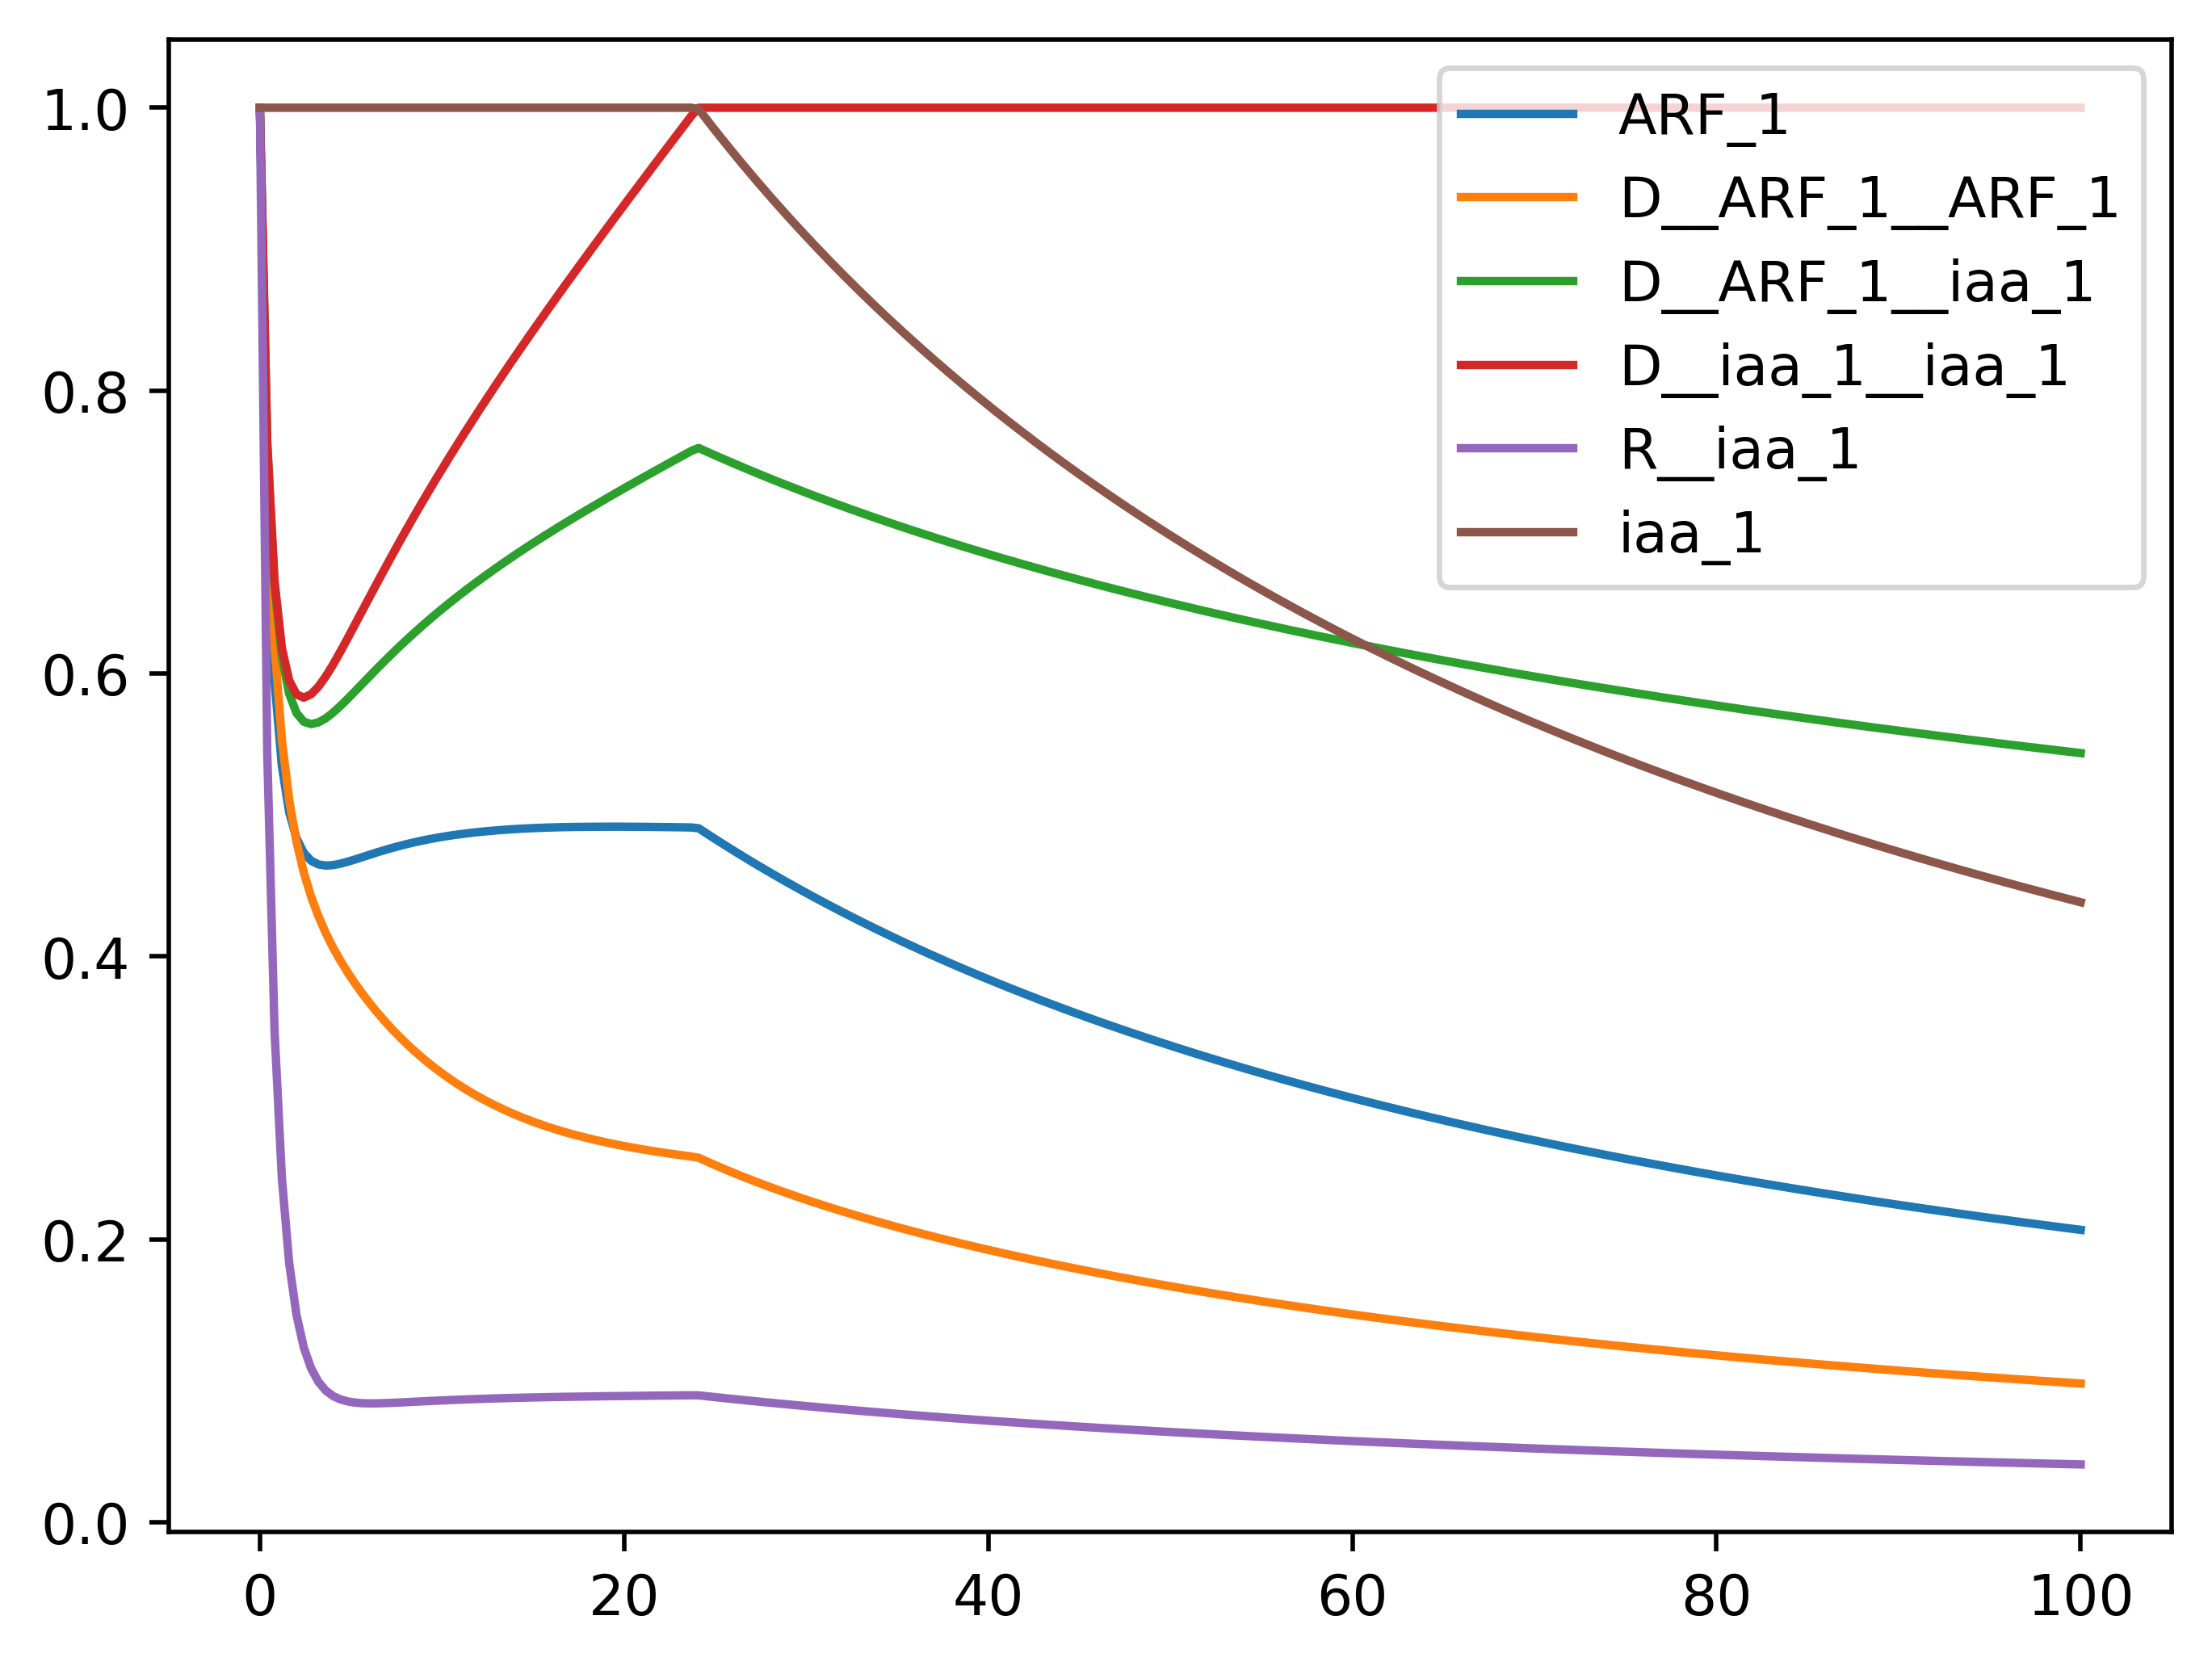

In [3]:
solver = asp_model.make_forward_solver()

ts = np.linspace(0, 100, 250)

aux_level = 1.0
default_output, success = solver(ts, default_parameters,
                            default_initial_conditions,
                            1.0)

import matplotlib.pyplot as plt
plt.plot(ts, default_output / default_output.max(axis=1)[:, None],
         label=list(default_initial_conditions))
plt.legend()
plt.show()

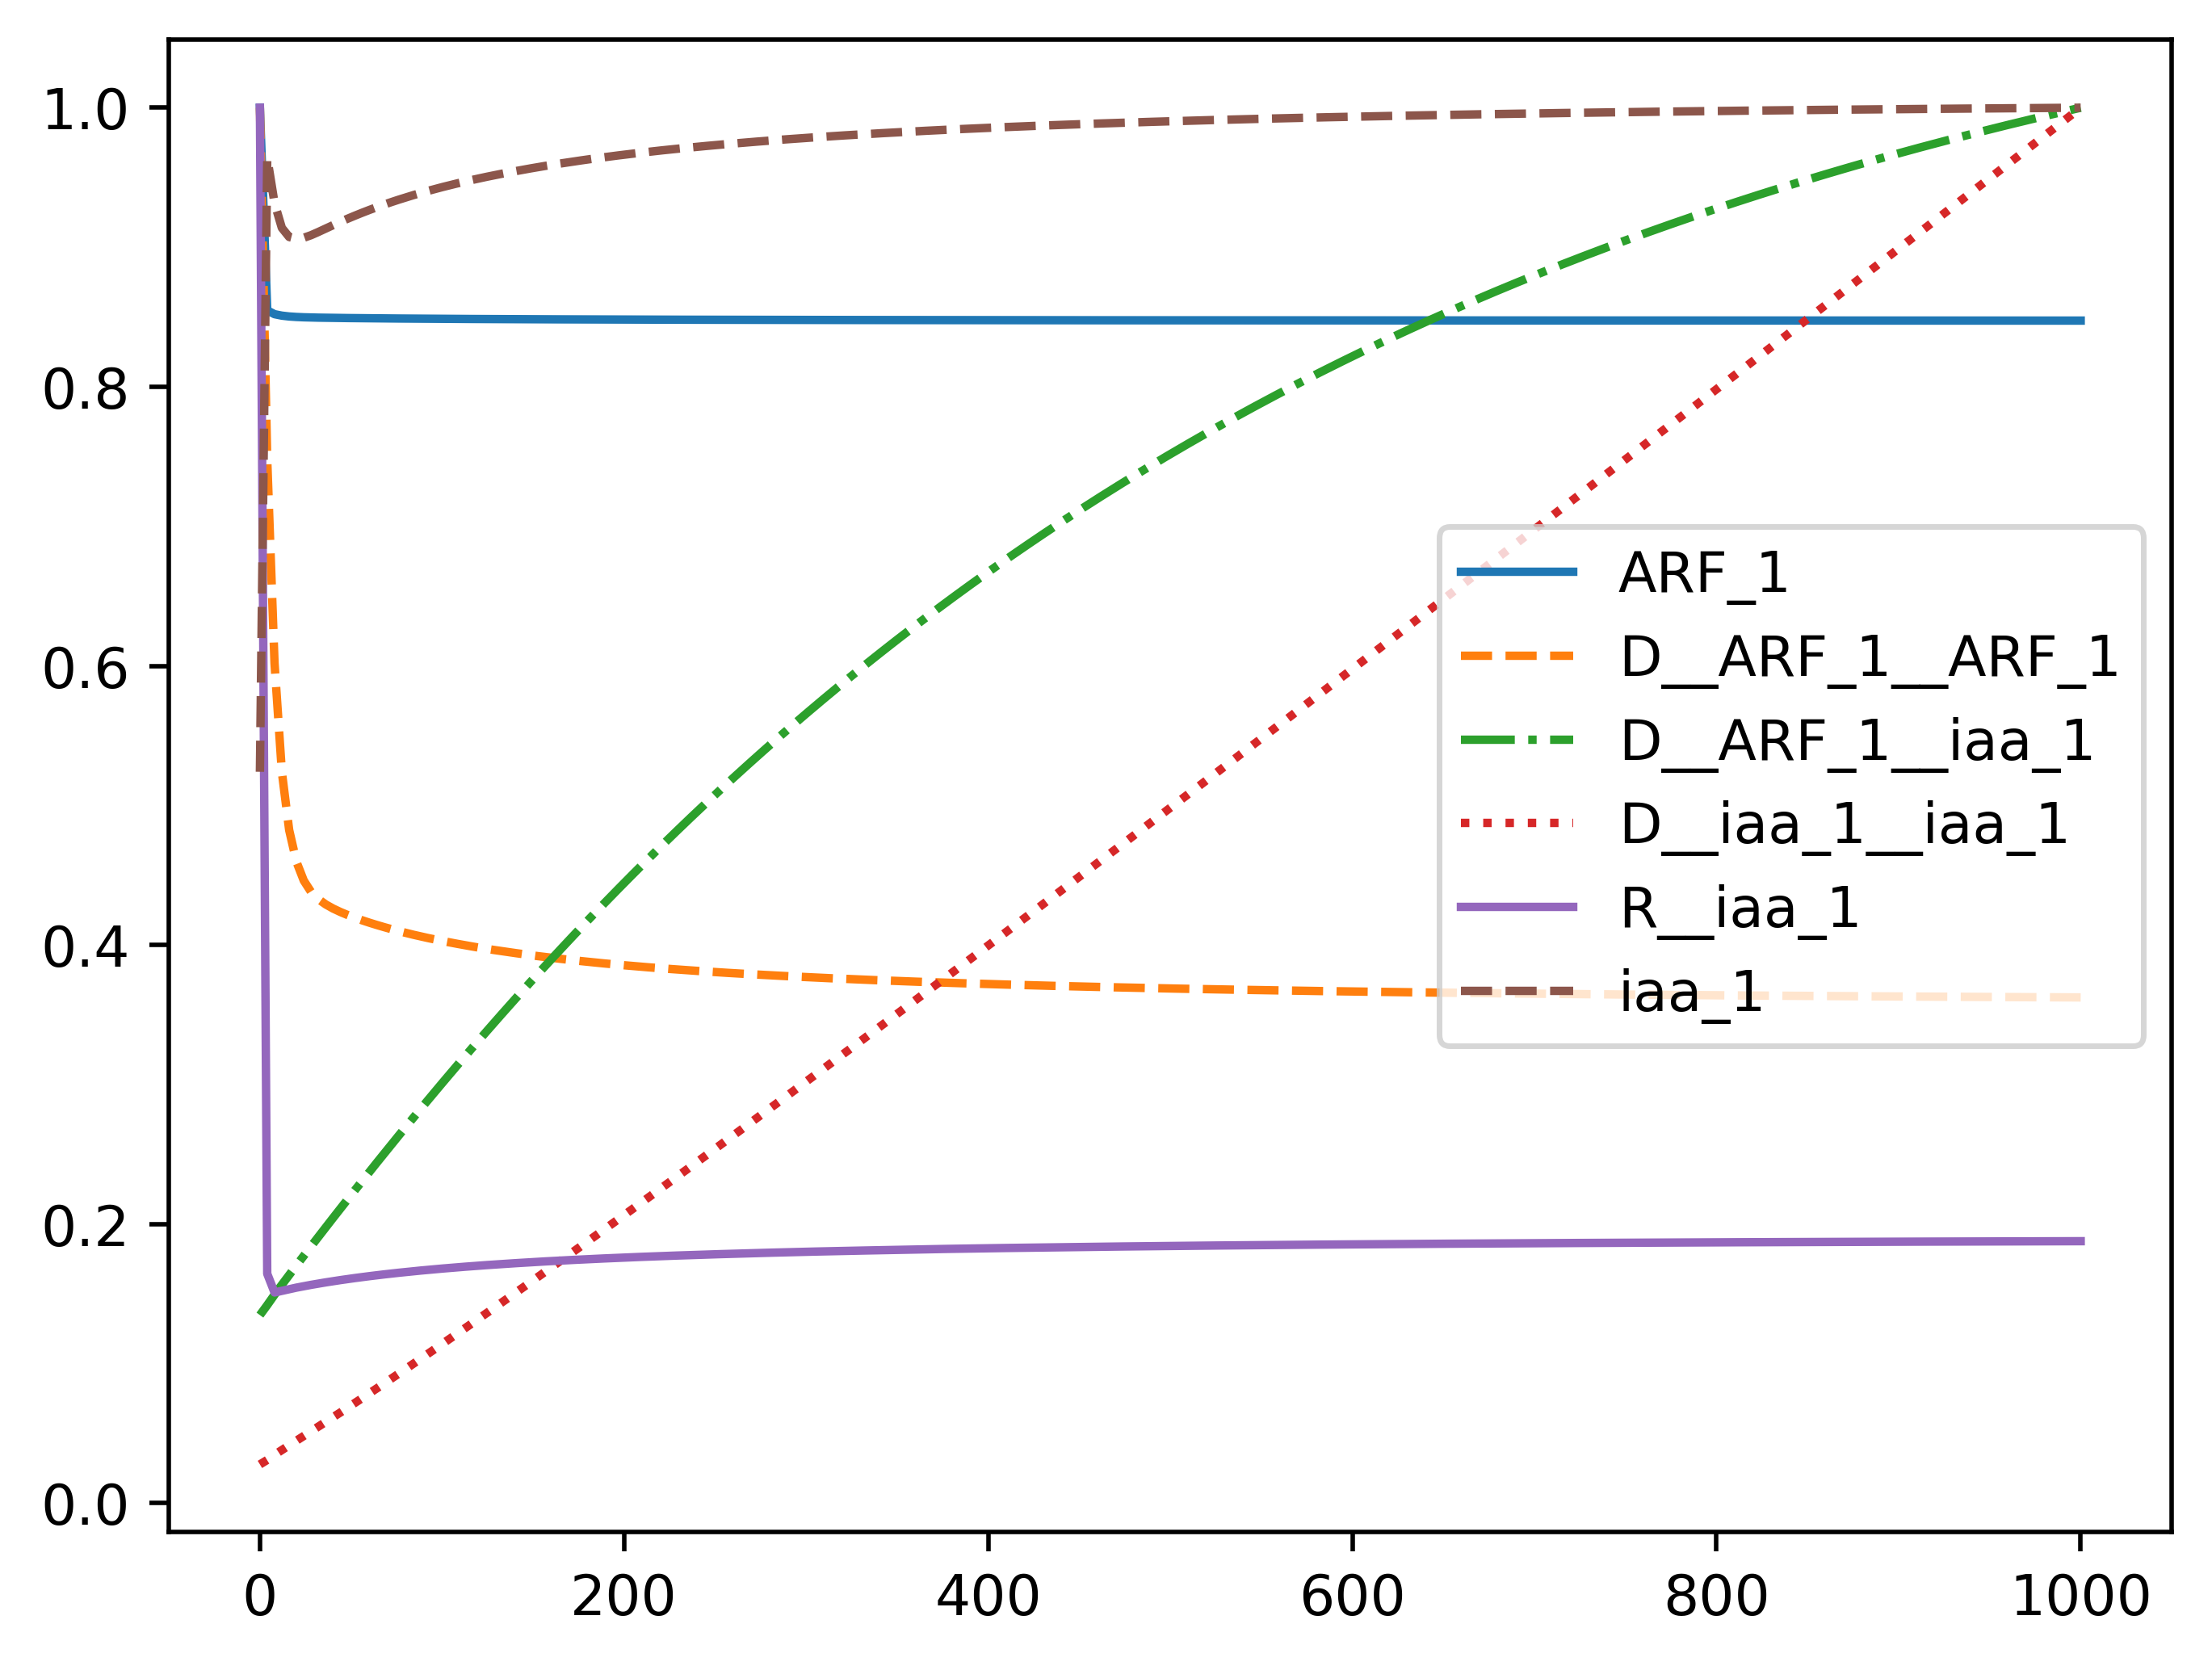

In [4]:
custom_parameters = \
{'arf__d': 1.0,
 'arf__k': 1.0,
 'd__D__ARF_1__ARF_1': 0.1,
 'd__D__ARF_1__iaa_1': 0.1,
 'd__D__iaa_1__iaa_1': 100,
 'd__G__ARF_1': 0.01,
 'd__G__ARF_1__ARF_1': 0.01,
 'd__G__ARF_1__ARF_1__unbind__ARF_1': 0.0,
 'd__G__ARF_1__iaa_1': 0.01,
 'd__G__ARF_1__iaa_1__unbind__iaa_1': 0.0,
 'd__R': 0.004166666666666667,
 'd__iaa_1_x': 5000,
 'iaa__d': 1.0,
 'iaa__k': 0,
 'k__D__ARF_1__ARF_1': 0.25,
 'k__D__ARF_1__iaa_1': 0.25,
 'k__D__iaa_1__iaa_1': 0.001,
 'k__G__ARF_1': 0.1,
 'k__G__ARF_1__ARF_1': 0.1,
 'k__G__ARF_1__ARF_1__R__iaa_1': 1.0,
 'k__G__ARF_1__R__iaa_1': 1.0,
 'k__G__ARF_1__bind__ARF_1': 0.0,
 'k__G__ARF_1__bind__iaa_1': 0.0,
 'k__G__ARF_1__iaa_1': 0.1,
 'k__G__ARF_1__iaa_1__R__iaa_1': 1.0,
 'k__G__R__iaa_1': 1.0,
 'k__R': 0.01,
 'k__RNA__IAA': 0.001,
 'k__iaa_1': 0.0}

ts = np.linspace(0, 1000, 250)

diff = { k : (custom_parameters[k], default_parameters[k]) for k in list(custom_parameters.keys()) + list(default_parameters.keys())
        if custom_parameters[k] != default_parameters[k]
       }

output, success = solver(ts, custom_parameters,
                            default_initial_conditions,
                            1.0)
import matplotlib.pyplot as plt
from itertools import cycle
lines = ["-","--","-.",":"]
linecycler = cycle(lines)
# output = output / output[:, i].max()

for i in range(output.shape[1]):
    plt.plot(ts, output[:, i]/output[:, i].max() , label=list(default_initial_conditions)[i],
            linestyle=next(linecycler))
plt.legend()
plt.show()
